In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_kpis_hbar_grouped(
    df: pd.DataFrame,
    title: str,
    vline_at_one: bool = True,
    group_gap: float = 1.6,
    bar_height: float = 0.10,
    label_dx: float = 0.02,
):
    """
    df: wide dataframe with columns: ["KPI", controller1, controller2, ...]
    """
    if "KPI" not in df.columns:
        raise ValueError("df must contain a 'KPI' column.")

    controllers = [c for c in df.columns if c != "KPI"]

    # 1) drop rows where all controller values are 0
    df = df[(df[controllers] != 0).any(axis=1)].copy()

    # build y positions with big gaps between KPI groups
    n_kpis = len(df)
    n_ctrl = len(controllers)

    y_groups = []
    y0 = 0.0
    for _ in range(n_kpis):
        ys = y0 + np.arange(n_ctrl) * bar_height
        y_groups.append(ys)
        y0 += group_gap

    # size: scale with number of KPIs
    fig_h = max(6, 0.75 * n_kpis)
    fig, ax = plt.subplots(figsize=(12, fig_h))

    # plot bars
    for i, ctrl in enumerate(controllers):
        vals = df[ctrl].to_numpy(dtype=float)
        ys = np.array([g[i] for g in y_groups], dtype=float)
        ax.barh(ys, vals, height=bar_height, label=ctrl)

        # value labels
        for y, v in zip(ys, vals):
            ax.text(v + label_dx, y, f"{v:.2f}", va="center", fontsize=9)

    # y tick at center of each group
    centers = [float(np.mean(g)) for g in y_groups]
    ax.set_yticks(centers)
    ax.set_yticklabels(df["KPI"].tolist())

    # separators between KPI groups (visual spacing)
    for g in y_groups:
        ax.axhline(g[-1] + bar_height * 1.5, color="lightgray", linewidth=0.6, zorder=0)

    # optional reference line at 1.0
    if vline_at_one:
        ax.axvline(1.0, linestyle="--", color="black", linewidth=1)

    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", framealpha=0.0)
    plt.tight_layout()
    plt.show()

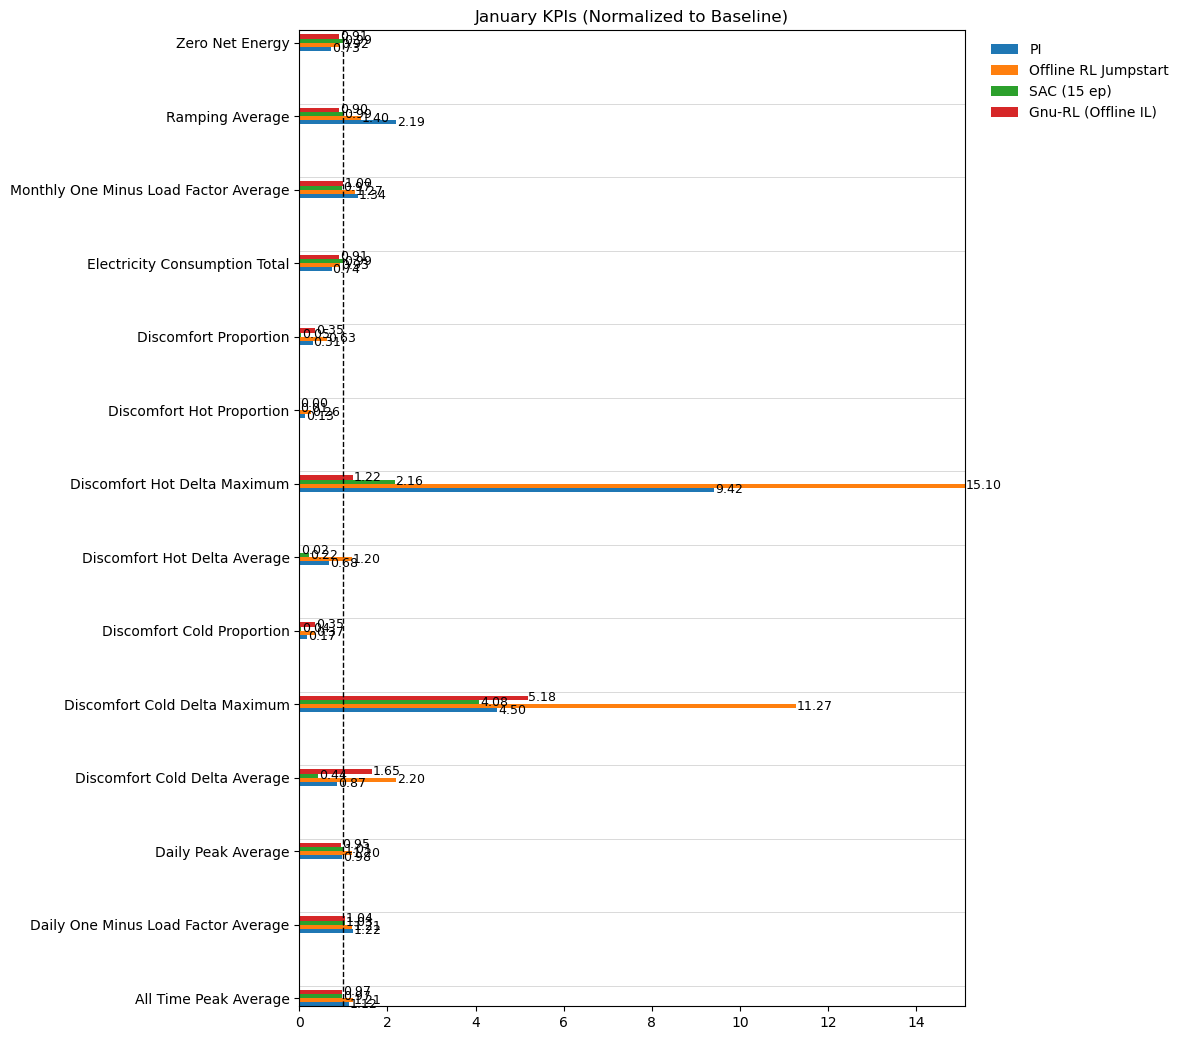

In [54]:
JAN = pd.DataFrame({
    "KPI": [
        "All Time Peak Average",
        "Annual Normalized Unserved Energy Total",
        "Daily One Minus Load Factor Average",
        "Daily Peak Average",
        "Discomfort Cold Delta Average",
        "Discomfort Cold Delta Maximum",
        "Discomfort Cold Delta Minimum",
        "Discomfort Cold Proportion",
        "Discomfort Hot Delta Average",
        "Discomfort Hot Delta Maximum",
        "Discomfort Hot Delta Minimum",
        "Discomfort Hot Proportion",
        "Discomfort Proportion",
        "Electricity Consumption Total",
        "Monthly One Minus Load Factor Average",
        "Ramping Average",
        "Zero Net Energy",
    ],
    "PI": [
        1.119600, 0.0, 1.221737, 0.976627,
        0.866836, 4.497313, 0.0, 0.172943,
        0.680757, 9.417515, 0.0, 0.132497,
        0.305439, 0.735004, 1.336461,
        2.190279, 0.728521,
    ],
    "Offline RL Jumpstart": [
        1.214316, 0.0, 1.206665, 1.199003,
        2.201122, 11.266287, 0.0, 0.366806,
        1.200229, 15.100410, 0.0, 0.264993,
        0.631799, 0.926722, 1.269230,
        1.399979, 0.924846,
    ],
    "SAC (15 ep)": [
        0.967056, 0.0, 1.027968, 1.007196,
        0.437136, 4.082966, 0.0, 0.043236,
        0.221028, 2.164660, 0.0, 0.006974,
        0.050209, 0.988161, 0.972855,
        0.993653, 0.988161,
    ],
    "Gnu-RL (Offline IL)": [
        0.965459, 0.0, 1.039263, 0.952122,
        1.645595, 5.181893, 0.0, 0.352859,
        0.016464, 1.220644, 0.0, 0.0,
        0.352859, 0.911382, 1.003897,
        0.897481, 0.911382,
    ],
})

plot_kpis_hbar_grouped(
    JAN,
    title="January KPIs (Normalized to Baseline)",
    vline_at_one=True,
    group_gap=1.8,      # more space between KPI categories
    bar_height=0.10,
    label_dx=0.02,
)

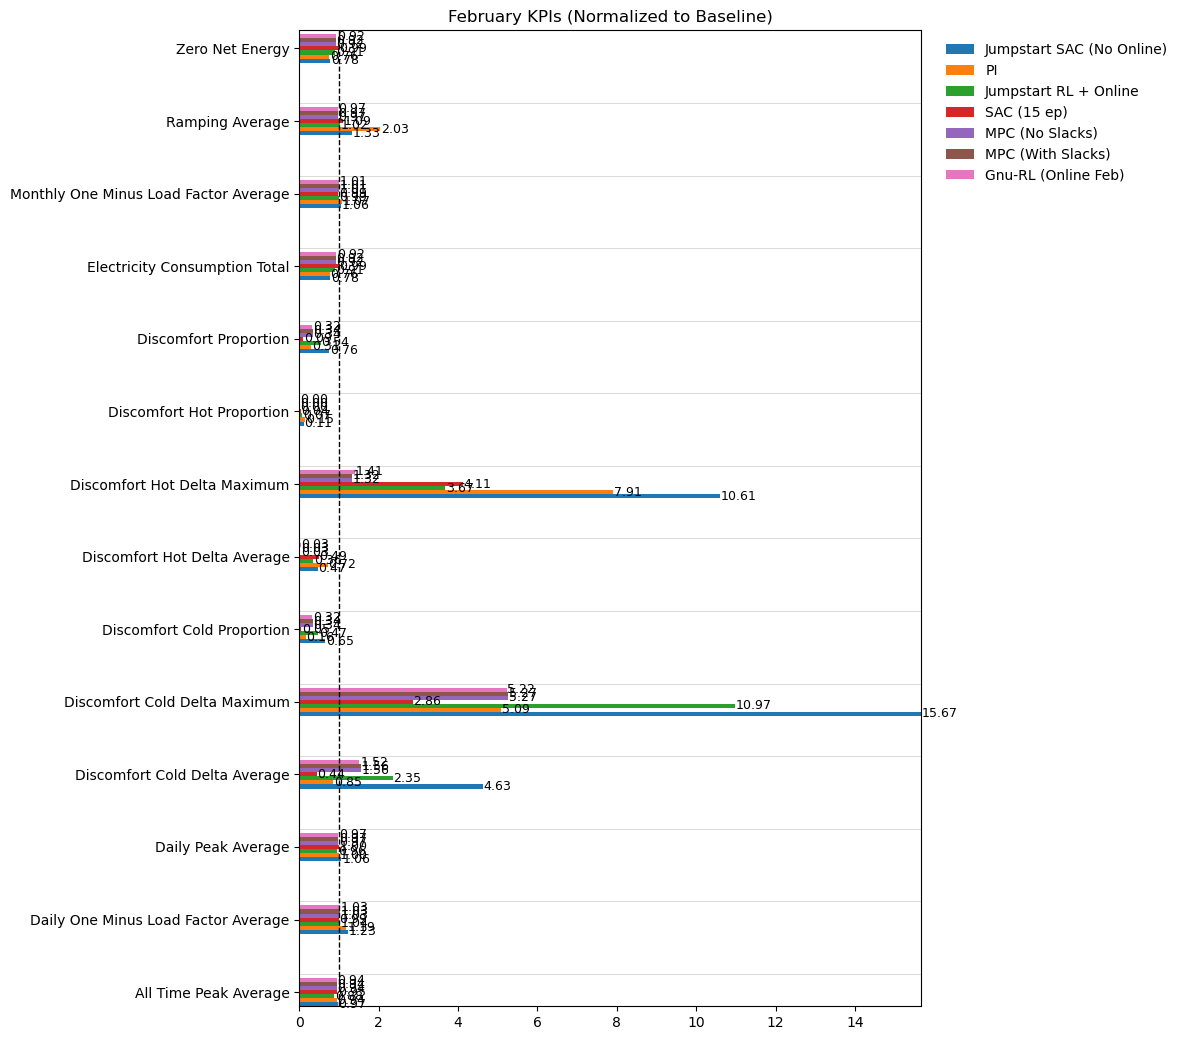

In [56]:
FEB = pd.DataFrame({
    "KPI": [
        "All Time Peak Average",
        "Annual Normalized Unserved Energy Total",
        "Daily One Minus Load Factor Average",
        "Daily Peak Average",
        "Discomfort Cold Delta Average",
        "Discomfort Cold Delta Maximum",
        "Discomfort Cold Delta Minimum",
        "Discomfort Cold Proportion",
        "Discomfort Hot Delta Average",
        "Discomfort Hot Delta Maximum",
        "Discomfort Hot Delta Minimum",
        "Discomfort Hot Proportion",
        "Discomfort Proportion",
        "Electricity Consumption Total",
        "Monthly One Minus Load Factor Average",
        "Ramping Average",
        "Zero Net Energy",
    ],
    "Jumpstart SAC (No Online)": [
        0.967581, 0.0, 1.225451, 1.062499,
        4.625309, 15.669895, 0.0, 0.647328,
        0.467457, 10.607216, 0.0, 0.108397,
        0.755725, 0.781352, 1.059396,
        1.325533, 0.779172,
    ],
    "PI": [
        0.941282, 0.0, 1.190129, 0.998428,
        0.851214, 5.089184, 0.0, 0.161832,
        0.717768, 7.912468, 0.0, 0.145038,
        0.306870, 0.762693, 1.065755,
        2.032633, 0.757148,
    ],
    "Jumpstart RL + Online": [
        0.884271, 0.0, 1.035626, 0.958983,
        2.353055, 10.971587, 0.0, 0.470229,
        0.356845, 3.673580, 0.0, 0.071756,
        0.541985, 0.906207, 0.991921,
        1.019516, 0.906207,
    ],
    "SAC (15 ep)": [
        0.948917, 0.0, 0.993435, 1.001917,
        0.438222, 2.859247, 0.0, 0.053435,
        0.486548, 4.113190, 0.0, 0.038168,
        0.091603, 0.990130, 0.985994,
        1.091798, 0.990130,
    ],
    "MPC (No Slacks)": [
        0.939643, 0.0, 1.027593, 0.972927,
        1.561982, 5.268160, 0.0, 0.338931,
        0.026983, 1.320217, 0.0, 0.0,
        0.338931, 0.920680, 1.006346,
        0.966078, 0.920680,
    ],
    "MPC (With Slacks)": [
        0.939643, 0.0, 1.028271, 0.973038,
        1.562967, 5.268160, 0.0, 0.338931,
        0.027016, 1.320217, 0.0, 0.0,
        0.338931, 0.920066, 1.006551,
        0.970553, 0.920066,
    ],
    "Gnu-RL (Online Feb)": [
        0.941505, 0.0, 1.026858, 0.974707,
        1.516104, 5.221968, 0.0, 0.322137,
        0.034765, 1.407623, 0.0, 0.0,
        0.322137, 0.923689, 1.005945,
        0.969891, 0.923689,
    ],
})

plot_kpis_hbar_grouped(
    FEB,
    title="February KPIs (Normalized to Baseline)",
    vline_at_one=True,
    group_gap=1.8,
    bar_height=0.10,
    label_dx=0.02,
)

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_with_numbers(df, title):

    controllers = [c for c in df.columns if c != "KPI"]

    # Remove rows where all controllers are zero
    df = df[(df[controllers] != 0).any(axis=1)].copy()

    # Melt
    df_melt = df.melt(
        id_vars="KPI",
        var_name="Controller",
        value_name="Value"
    )

    # Figure size scales with number of KPIs
    plt.figure(figsize=(13, 0.8 * len(df)))

    ax = sns.barplot(
        data=df_melt,
        x="Value",
        y="KPI",
        hue="Controller",
        dodge=True
    )

    # Add value labels cleanly
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.2f",
            padding=3,
            fontsize=9
        )

    # Reference line
    plt.axvline(1.0, linestyle="--", color="black", linewidth=1)

    plt.title(title, fontsize=14)
    plt.xlabel("")
    plt.ylabel("")

    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

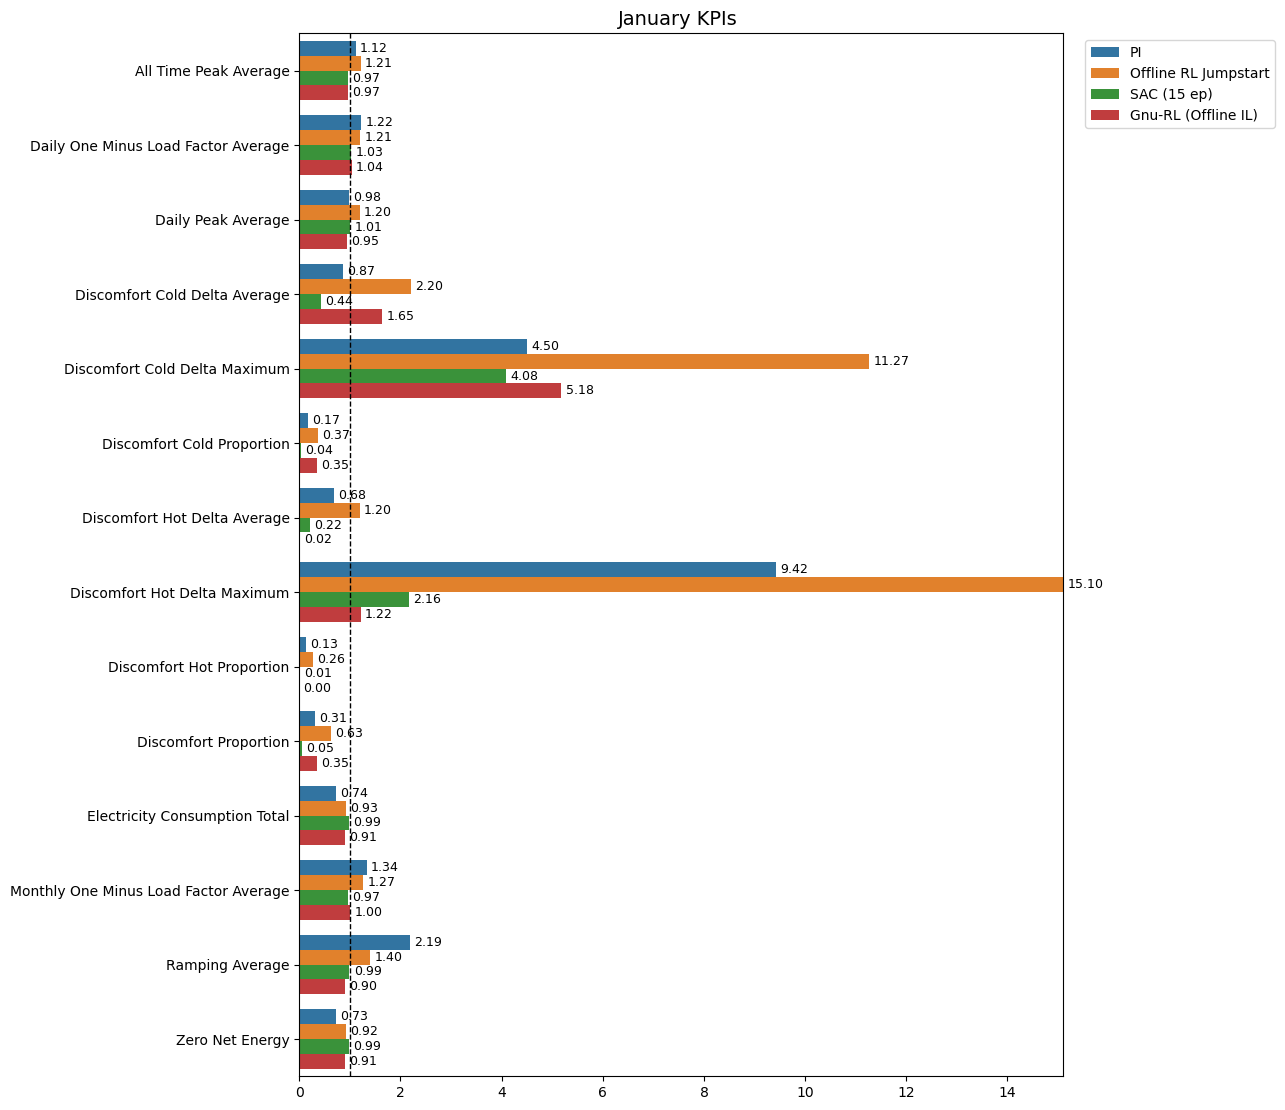

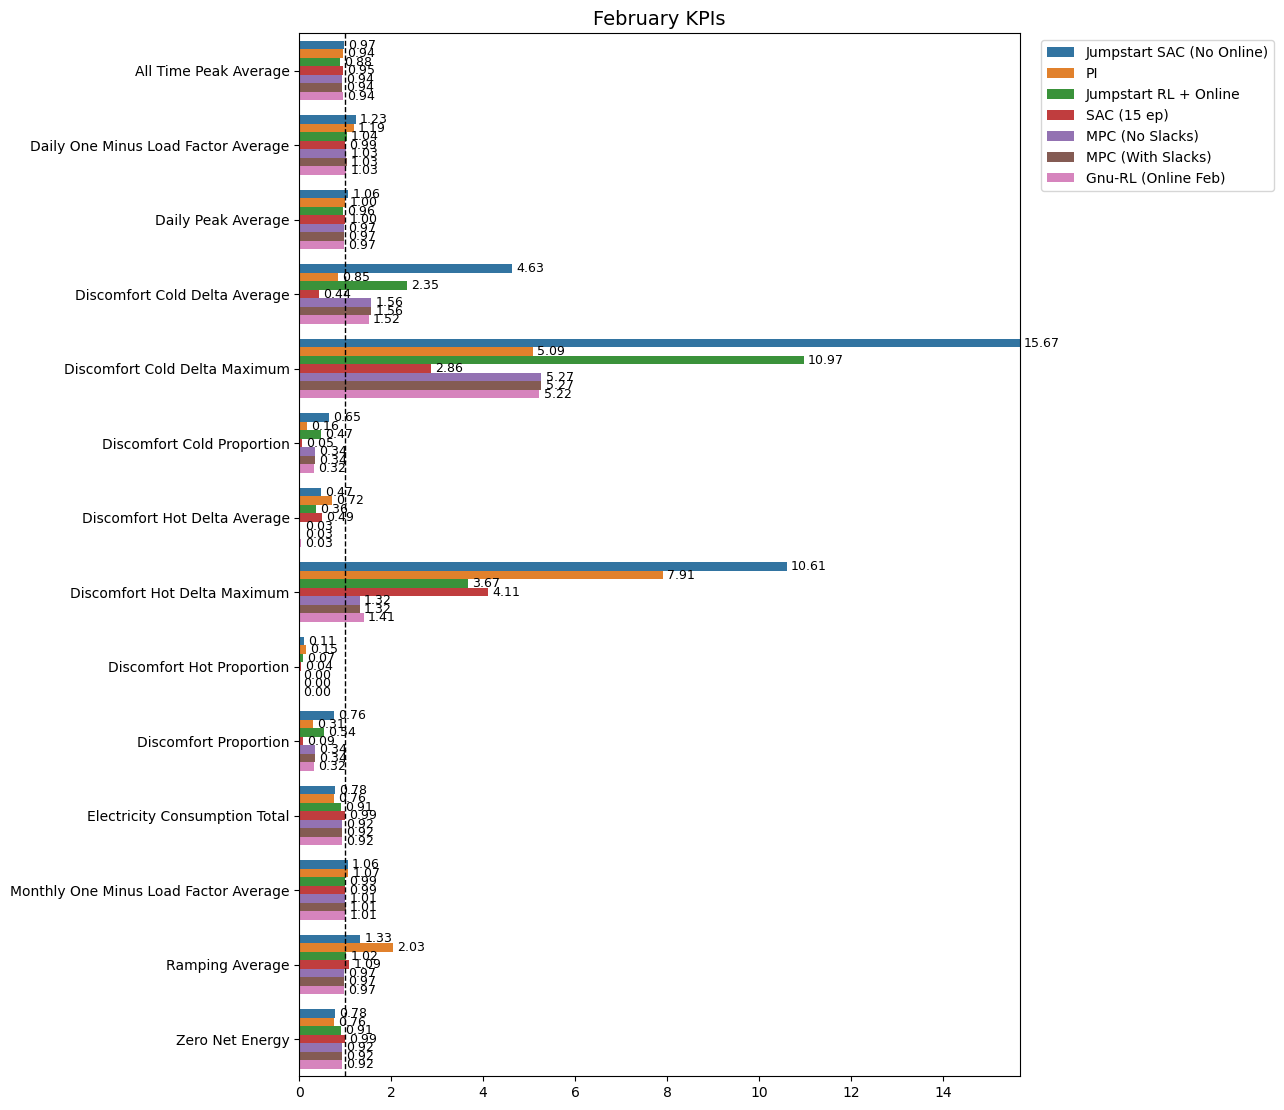

In [62]:
plot_with_numbers(JAN, "January KPIs ")
plot_with_numbers(FEB, "February KPIs")

In [1]:
import os
import sys
from pathlib import Path

# Where the notebook actually lives
NOTEBOOK_DIR = Path(os.getcwd())

# Repo root = parent of notebooks
REPO_DIR = NOTEBOOK_DIR.parent

print("Notebook directory:", NOTEBOOK_DIR)
print("Repo directory:", REPO_DIR)

# Force CityLearn from cloned repo (optional, see note below)
sys.path.insert(0, str(REPO_DIR))

import citylearn
print("✅ citylearn loaded from:", citylearn.__file__)

# Choose climate: TX or VT
CLIMATE = "VT"  # or "VT"

DATASET_DIR = REPO_DIR / "data" / "datasets" / f"annex96_ce1_{CLIMATE.lower()}_neighborhood"
SCHEMA_PATH = DATASET_DIR / "schema.json"

print("\nClimate:", CLIMATE)
print("Dataset directory:", DATASET_DIR, "| exists:", DATASET_DIR.exists())
print("Schema path:", SCHEMA_PATH, "| exists:", SCHEMA_PATH.exists())


Notebook directory: /home/kostas/school/Y2/Zoltan/annex96_common_exercise_1/notebooks
Repo directory: /home/kostas/school/Y2/Zoltan/annex96_common_exercise_1
✅ citylearn loaded from: /home/kostas/school/Y2/Zoltan/annex96_common_exercise_1/citylearn/__init__.py

Climate: VT
Dataset directory: /home/kostas/school/Y2/Zoltan/annex96_common_exercise_1/data/datasets/annex96_ce1_vt_neighborhood | exists: True
Schema path: /home/kostas/school/Y2/Zoltan/annex96_common_exercise_1/data/datasets/annex96_ce1_vt_neighborhood/schema.json | exists: True


In [2]:
import pandas as pd

district_target_df = pd.read_csv(DATASET_DIR / "district_target.csv")
district_target = district_target_df["district_load_target"].values

In [3]:
# system operations
import inspect
import os
import sys
import uuid
import warnings

# date and time
import datetime

# type hinting
from typing import Any

# User interaction
from ipywidgets import Button, HTML
from ipywidgets import Text, HBox, VBox

# data visualization
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from tqdm import tqdm

# data manipulation
from bs4 import BeautifulSoup
import math
import numpy as np
import pandas as pd
import random
import re
import requests
import simplejson as json

# cityLearn
from citylearn.agents.base import (
    BaselineAgent,
    Agent as RandomAgent
)
from citylearn.agents.rbc import HourRBC
from citylearn.agents.q_learning import TabularQLearning
from citylearn.citylearn import CityLearnEnv
from citylearn.data import DataSet
from citylearn.reward_function import RewardFunction, ComfortReward
from citylearn.wrappers import (
    NormalizedObservationWrapper,
    StableBaselines3Wrapper,
    TabularQLearningWrapper
)
from citylearn.agents.rbc import TemperatureBasedRBC
from citylearn.agents.rbc import PITemperatureController, PIDTemperatureController

# RL algorithms
from stable_baselines3 import SAC, PPO
import do_mpc

Couldn't import dot_parser, loading of dot files will not be possible.


2026-02-24 12:52:56.921581: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-24 12:52:57.118289: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-24 12:52:57.177475: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-24 12:52:57.190699: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-24 12:52:57.282258: I tensorflow/core/platform/cpu_feature_guar

In [4]:
# set all plotted figures without margins
plt.rcParams['axes.xmargin'] = 0
plt.rcParams['axes.ymargin'] = 0
%matplotlib inline

# ignore deprecation warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

In [5]:
import json
import pandas as pd

# Load schema.json
with open(SCHEMA_PATH, "r") as f:
    schema = json.load(f)
root_directory = DATASET_DIR
print("Root directory:", root_directory)

Root directory: /home/kostas/school/Y2/Zoltan/annex96_common_exercise_1/data/datasets/annex96_ce1_vt_neighborhood


In [6]:
building_name = 'resstock-amy2018-2021-release-1-247942'

filename = schema["buildings"][building_name]["energy_simulation"]
filepath = root_directory / filename

print("CSV file:", filepath, "| exists:", filepath.exists())

CSV file: /home/kostas/school/Y2/Zoltan/annex96_common_exercise_1/data/datasets/annex96_ce1_vt_neighborhood/resstock-amy2018-2021-release-1-247942.csv | exists: True


In [7]:
import importlib, helpers
importlib.reload(helpers)
from helpers import select_buildings, select_simulation_period, get_kpis, plot_building_kpis, plot_district_kpis, plot_building_load_profiles, plot_district_load_profiles, plot_battery_soc_profiles, plot_comfort, plot_comfort_with_lstm_1step, make_env, run_env, plot_simulation_summary





In [8]:
RANDOM_SEED = 42
BUILDING_COUNT = 1

BUILDINGS = select_buildings(
    schema=schema,
    count=BUILDING_COUNT,
    seed=RANDOM_SEED,
)

print("Selected building(s):", BUILDINGS)


Selected building(s): ['resstock-amy2018-2021-release-1-247942']


In [9]:
RANDOM_SEED = 42
SIM_DAYS = 14  # two weeks

SIMULATION_START_TIME_STEP, SIMULATION_END_TIME_STEP = select_simulation_period(
    schema=schema,
    dataset_dir=DATASET_DIR,
    count=SIM_DAYS,
    seed=RANDOM_SEED
)

CENTRAL_AGENT = True

print("Simulation start:", SIMULATION_START_TIME_STEP)
print("Simulation end:", SIMULATION_END_TIME_STEP)
print("Duration (hours):", SIMULATION_END_TIME_STEP - SIMULATION_START_TIME_STEP + 1)


Simulation start: 0
Simulation end: 335
Duration (hours): 336


In [10]:
def make_env(
    reward_function=None,
    simulation_start_time_step=None,
    simulation_end_time_step=None,
    **kwargs
):
    """
    Create a CityLearn environment with optional reward function override.
    """

    base_kwargs = dict(
        schema=str(SCHEMA_PATH),
        root_directory=str(DATASET_DIR),
        central_agent=CENTRAL_AGENT,
        buildings=BUILDINGS,
        simulation_start_time_step=simulation_start_time_step
            if simulation_start_time_step is not None
            else SIMULATION_START_TIME_STEP,
        simulation_end_time_step=simulation_end_time_step
            if simulation_end_time_step is not None
            else SIMULATION_END_TIME_STEP,
        active_actions=[
            'heating_device',
        ],
    )

    # Inject reward function if provided
    if reward_function is not None:
        base_kwargs["reward_function"] = reward_function

    # Allow further overrides
    base_kwargs.update(kwargs)

    return CityLearnEnv(**base_kwargs)

In [11]:
def run_env(env, agent):
    obs, info = env.reset()
    terminated = False
    truncated = False

    while not (terminated or truncated):
        actions = agent.predict(obs)
        obs, reward, terminated, truncated, info = env.step(actions)

    return env

In [12]:
import numpy as np

def collect_trajectories(env, agent, save_path=None):
    """
    Run controller in CityLearn and collect RL transitions:
    (state, action, reward, next_state, done)
    """

    states, actions, rewards, next_states, dones = [], [], [], [], []

    obs, info = env.reset()
    terminated = False
    truncated = False

    while not (terminated or truncated):
        action = agent.predict(obs)

        next_obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # store transition
        states.append(obs)
        actions.append(action)
        rewards.append(reward)
        next_states.append(next_obs)
        dones.append(done)

        obs = next_obs

    dataset = {
        "states": np.array(states, dtype=np.float32),
        "actions": np.array(actions, dtype=np.float32),
        "rewards": np.array(rewards, dtype=np.float32),
        "next_states": np.array(next_states, dtype=np.float32),
        "dones": np.array(dones, dtype=np.float32),
    }

    # optional save
    if save_path is not None:
        np.savez_compressed(save_path, **dataset)
        print(f"Dataset saved to: {save_path}")

    return env, dataset


In [14]:
RANDOM_SEED = 49
SIM_DAYS = 31 # one month

SIMULATION_START_TIME_STEP, SIMULATION_END_TIME_STEP = select_simulation_period(
    schema=schema,
    dataset_dir=DATASET_DIR,
    count=SIM_DAYS,
    seed=RANDOM_SEED
)

CENTRAL_AGENT = True

print("Simulation start:", SIMULATION_START_TIME_STEP)
print("Simulation end:", SIMULATION_END_TIME_STEP)
print("Duration (hours):", SIMULATION_END_TIME_STEP - SIMULATION_START_TIME_STEP + 1)


Simulation start: 0
Simulation end: 743
Duration (hours): 744


/home/kostas/school/Y2/Zoltan/annex96_common_exercise_1/citylearn/dynamics.py:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(self.filepat

Dataset saved to: january_pi_dataset.npz


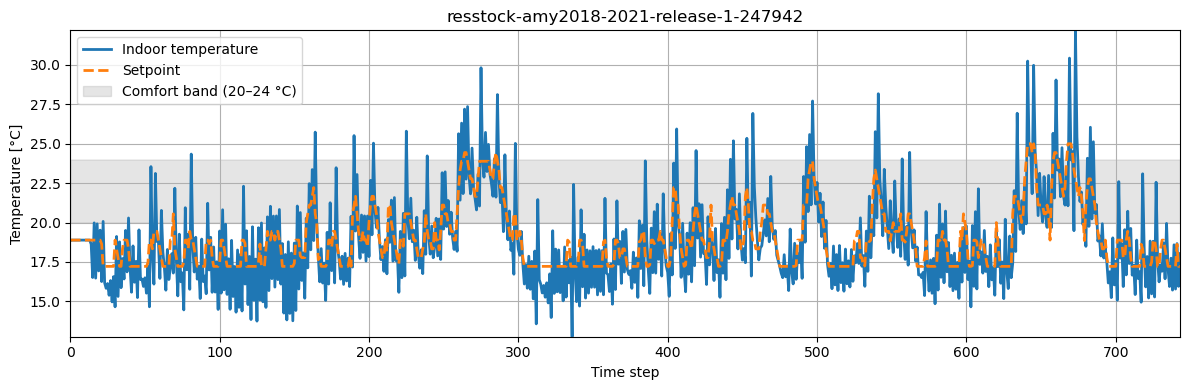

In [15]:
env_pi_rbc = make_env(
    reward_function=ComfortReward,
    simulation_start_time_step=SIMULATION_START_TIME_STEP,
    simulation_end_time_step=SIMULATION_END_TIME_STEP,
)

pi_rbc = PITemperatureController(env_pi_rbc)

env_pi, january_dataset = collect_trajectories(
    env_pi_rbc,
    pi_rbc,
    save_path="january_pi_dataset.npz"
)

plot_comfort(env_pi)

In [16]:
print(env_pi.unwrapped.evaluate())

                                    cost_function     value  \
0                           all_time_peak_average  1.119600   
1         annual_normalized_unserved_energy_total  0.000000   
2                          carbon_emissions_total       NaN   
3                                      cost_total       NaN   
4             daily_one_minus_load_factor_average  1.221737   
5                              daily_peak_average  0.976627   
6                   discomfort_cold_delta_average  0.866836   
7                   discomfort_cold_delta_maximum  4.497313   
8                   discomfort_cold_delta_minimum  0.000000   
9                      discomfort_cold_proportion  0.172943   
10                   discomfort_hot_delta_average  0.680757   
11                   discomfort_hot_delta_maximum  9.417515   
12                   discomfort_hot_delta_minimum  0.000000   
13                      discomfort_hot_proportion  0.132497   
14                          discomfort_proportion  0.30

In [17]:
env_baseline = make_env(
    reward_function=ComfortReward,
    simulation_start_time_step=SIMULATION_START_TIME_STEP,
    simulation_end_time_step=SIMULATION_END_TIME_STEP,
)
baseline_model = BaselineAgent(env_baseline)
baseline_temp = run_env(env_baseline, baseline_model)

/home/kostas/school/Y2/Zoltan/annex96_common_exercise_1/citylearn/dynamics.py:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(self.filepat

In [18]:
print(env_baseline.unwrapped.evaluate())

                                    cost_function     value  \
0                           all_time_peak_average  1.000000   
1         annual_normalized_unserved_energy_total  0.000000   
2                          carbon_emissions_total       NaN   
3                                      cost_total       NaN   
4             daily_one_minus_load_factor_average  1.000000   
5                              daily_peak_average  1.000000   
6                   discomfort_cold_delta_average  0.354771   
7                   discomfort_cold_delta_maximum  1.681904   
8                   discomfort_cold_delta_minimum  0.000000   
9                      discomfort_cold_proportion  0.000000   
10                   discomfort_hot_delta_average  0.154020   
11                   discomfort_hot_delta_maximum  1.588217   
12                   discomfort_hot_delta_minimum  0.000000   
13                      discomfort_hot_proportion  0.000000   
14                          discomfort_proportion  0.00

######## BUILDING-LEVEL ########
Building-level KPIs:


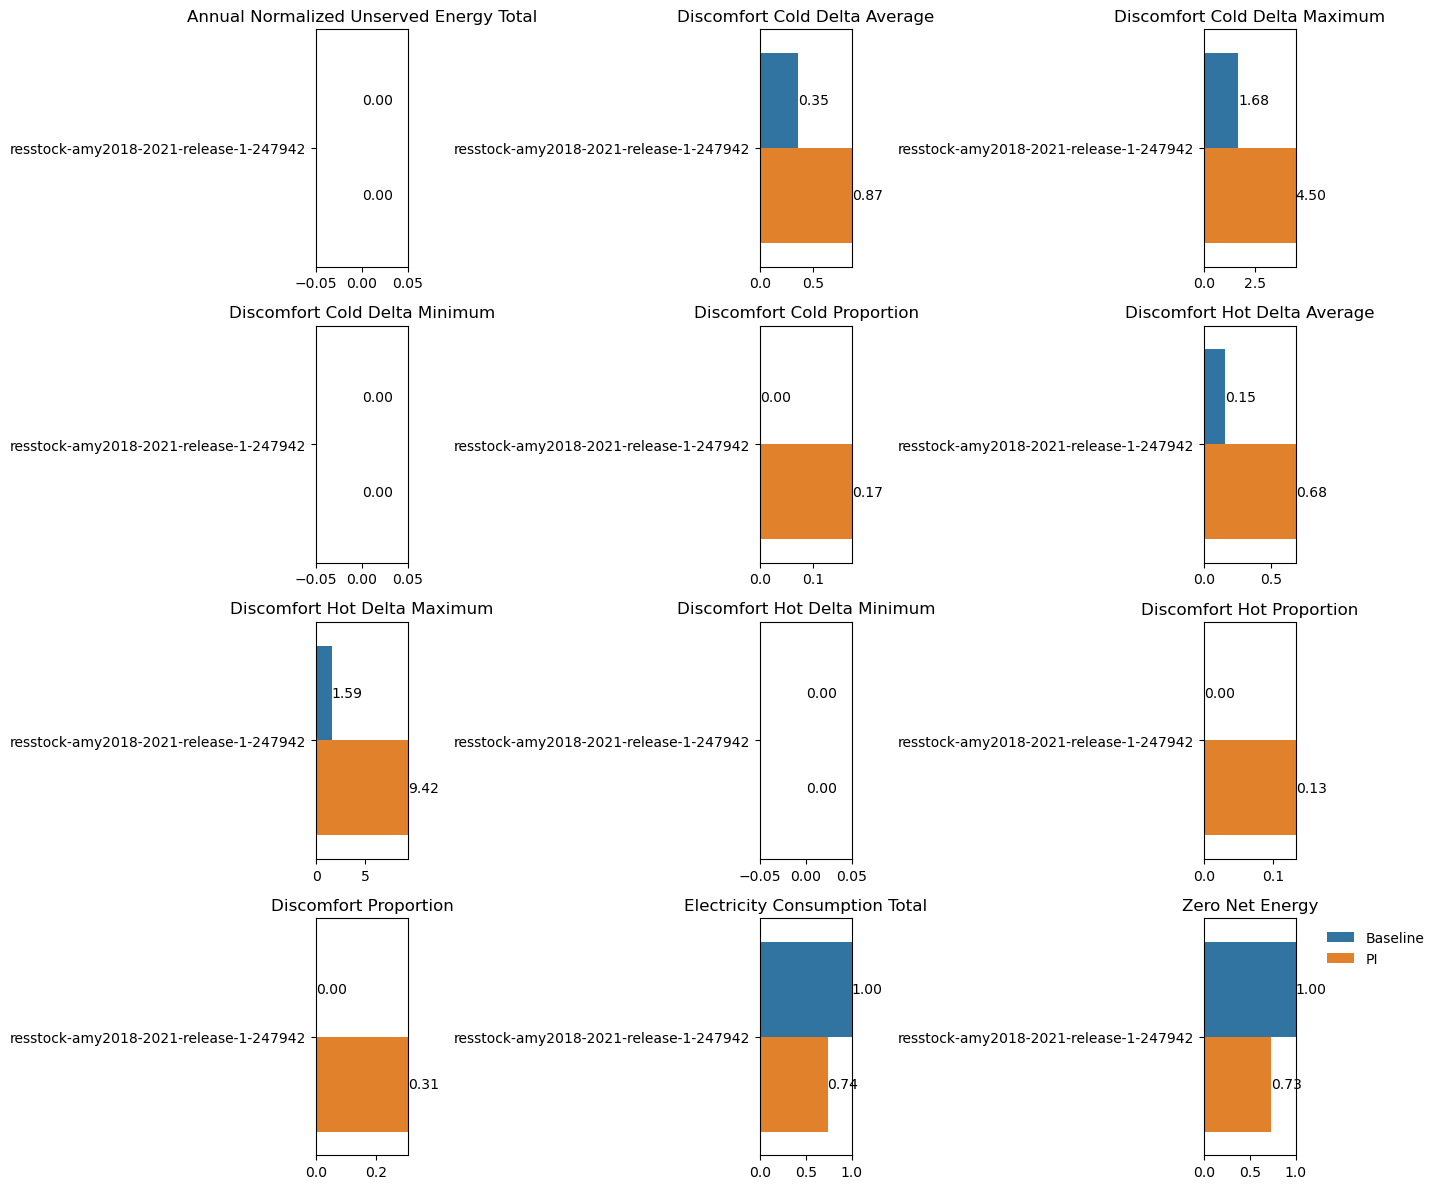

Building-level simulation period load profiles:


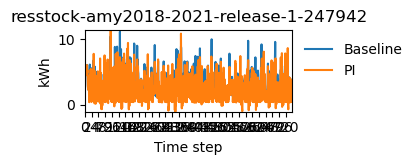

Building-level daily-average load profiles:


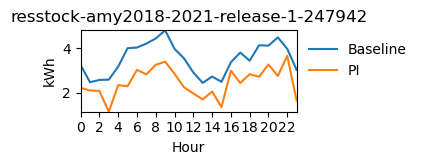

Battery SoC profiles:


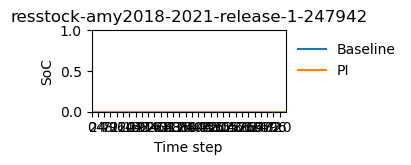

######## DISTRICT-LEVEL ########
District-level KPIs (ALL):


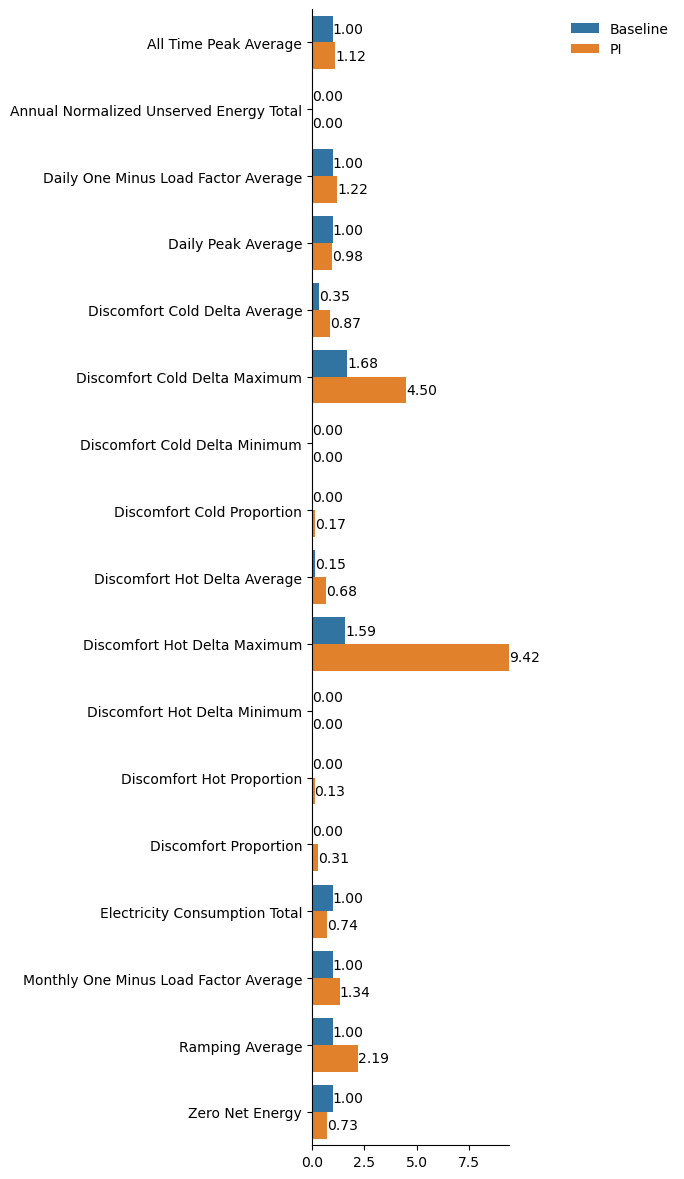

District-level simulation period load profiles:


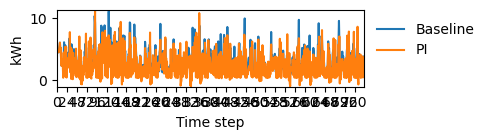

District-level daily-average load profiles:


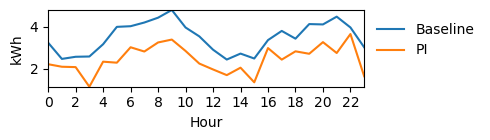

In [46]:
plot_simulation_summary({
    'Baseline': env_baseline,
    'PI': env_pi,
})

In [19]:
for k, v in january_dataset.items():
    print(k, v.shape, v.dtype)


states (743, 1, 28) float32
actions (743, 1, 1) float32
rewards (743, 1) float32
next_states (743, 1, 28) float32
dones (743,) float32


In [20]:
sac_env = make_env(reward_function=ComfortReward)
sac_env = NormalizedObservationWrapper(sac_env)
sac_env = StableBaselines3Wrapper(sac_env)


/home/kostas/school/Y2/Zoltan/annex96_common_exercise_1/citylearn/dynamics.py:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(self.filepat

In [21]:
from stable_baselines3 import SAC

sac_model = SAC(
    policy="MlpPolicy",
    env=sac_env,
    learning_starts=0,
    seed=RANDOM_SEED,
    verbose=1,
)


Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [22]:
import numpy as np

data = np.load("january_pi_dataset.npz")

states      = data["states"]        # (T, 1, 28)
actions     = data["actions"]       # (T, 1, 1)
rewards     = data["rewards"]       # (T, 1)
next_states = data["next_states"]   # (T, 1, 28)
dones       = data["dones"]         # (T,)


In [23]:
obs_dim_sac = sac_env.observation_space.shape[-1]   # 30
obs_dim_data = states.shape[-1]                     # 28
pad = obs_dim_sac - obs_dim_data                    # 2

def pad_obs(x):
    return np.pad(x, ((0,0),(0,0),(0,pad)), mode="constant")


In [24]:
states      = pad_obs(states)
next_states = pad_obs(next_states)


In [25]:
rb = sac_model.replay_buffer

for i in range(len(states)):
    rb.add(
        states[i],
        next_states[i],
        actions[i],
        float(rewards[i]),
        bool(dones[i]),
        infos={}
    )

print("Replay buffer size:", rb.size())


ValueError: could not broadcast input array from shape (0,) into shape (1,)

In [26]:
obs, _ = sac_env.reset()
print(obs.shape)


(30,)


/home/kostas/school/Y2/Zoltan/annex96_common_exercise_1/citylearn/dynamics.py:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(self.filepat

In [27]:
from stable_baselines3 import SAC
import numpy as np

# --- env (28-dim, no normalization wrapper) ---
sac_env = make_env(reward_function=ComfortReward)
sac_env = StableBaselines3Wrapper(sac_env)

# --- model ---
sac_model = SAC(
    policy="MlpPolicy",
    env=sac_env,
    learning_starts=0,
    seed=RANDOM_SEED,
    verbose=1,
)

# 🔴 REQUIRED for offline training
sac_model._setup_learn(total_timesteps=1)

# --- load PI dataset ---
data = np.load("january_pi_dataset.npz")

states      = data["states"]
actions     = data["actions"]
rewards     = data["rewards"]
next_states = data["next_states"]
dones       = data["dones"]

# --- fill replay buffer ---
rb = sac_model.replay_buffer

for i in range(len(states)):
    rb.add(
        states[i],
        next_states[i],
        actions[i],
        float(rewards[i].squeeze()),
        bool(dones[i]),
        infos=[{}],
    )

print("Replay buffer size:", rb.size())

# --- offline gradient training ---
GRADIENT_STEPS = 20_000
BATCH_SIZE = 256

for _ in range(GRADIENT_STEPS):
    sac_model.train(batch_size=BATCH_SIZE, gradient_steps=1)

# --- save ---
sac_model.save("sac_offline_from_PI_28dim")
print("✅ Offline SAC finished and saved.")


/home/kostas/school/Y2/Zoltan/annex96_common_exercise_1/citylearn/dynamics.py:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(self.filepat

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Replay buffer size: 743


KeyboardInterrupt: 

# Check what RL has learnt in January

In [28]:
eval_env = make_env(
    simulation_start_time_step=SIMULATION_START_TIME_STEP,
    simulation_end_time_step=SIMULATION_END_TIME_STEP,
    reward_function=ComfortReward,
)

eval_env = StableBaselines3Wrapper(eval_env)


/home/kostas/school/Y2/Zoltan/annex96_common_exercise_1/citylearn/dynamics.py:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(self.filepat

In [29]:
from stable_baselines3 import SAC

sac_model = SAC.load("sac_offline_from_PI_28dim", env=eval_env)


Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [30]:
obs, _ = eval_env.reset()
done = False

while not done:
    action, _ = sac_model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, _ = eval_env.step(action)
    done = terminated or truncated


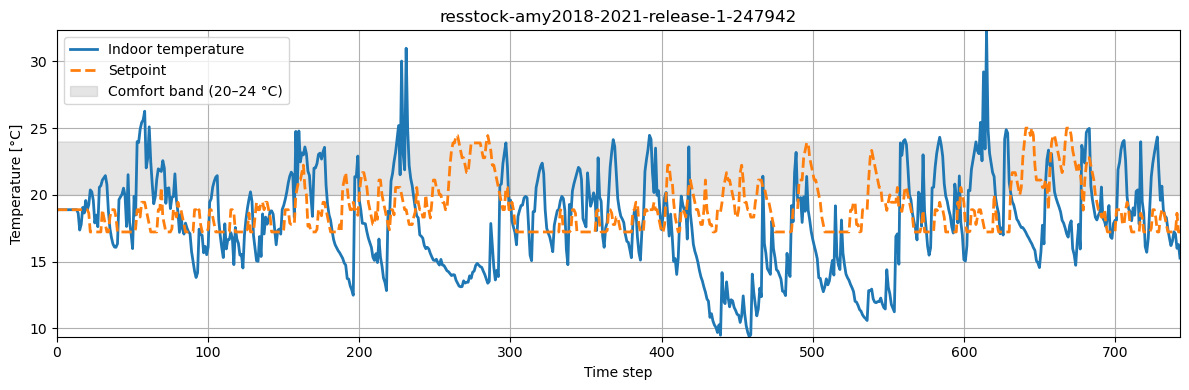

In [31]:
plot_comfort(eval_env)


In [32]:
print(eval_env.unwrapped.evaluate())

                                    cost_function      value  \
0                           all_time_peak_average   1.214316   
1         annual_normalized_unserved_energy_total   0.000000   
2                          carbon_emissions_total        NaN   
3                                      cost_total        NaN   
4             daily_one_minus_load_factor_average   1.206665   
5                              daily_peak_average   1.199003   
6                   discomfort_cold_delta_average   2.201122   
7                   discomfort_cold_delta_maximum  11.266287   
8                   discomfort_cold_delta_minimum   0.000000   
9                      discomfort_cold_proportion   0.366806   
10                   discomfort_hot_delta_average   1.200229   
11                   discomfort_hot_delta_maximum  15.100410   
12                   discomfort_hot_delta_minimum   0.000000   
13                      discomfort_hot_proportion   0.264993   
14                          discomfort_p

# Check what RL has learnt in February

/home/kostas/school/Y2/Zoltan/annex96_common_exercise_1/citylearn/dynamics.py:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(self.filepat

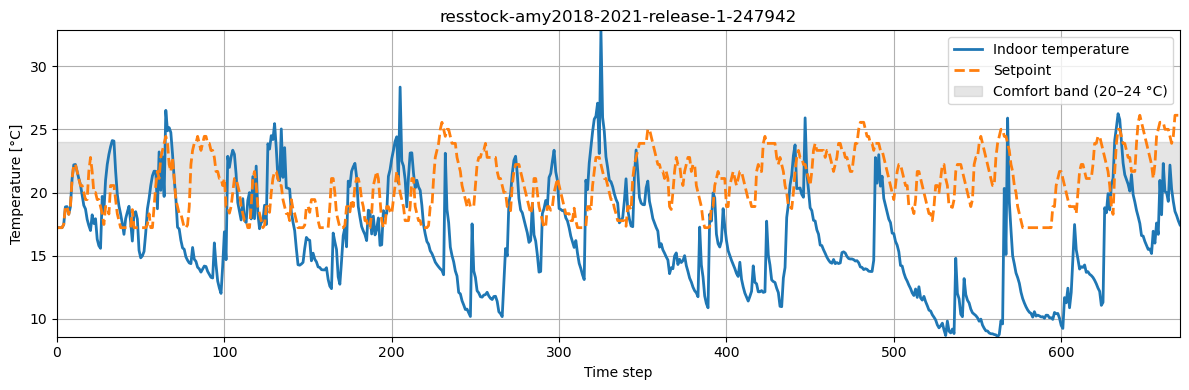

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (672,) + inhomogeneous part.

In [ ]:
FEB_START = SIMULATION_END_TIME_STEP + 1
FEB_END = FEB_START + (28)*24 - 1  # example

feb_env = make_env(
    simulation_start_time_step=FEB_START,
    simulation_end_time_step=FEB_END,
    reward_function=ComfortReward,
)
feb_env = StableBaselines3Wrapper(feb_env)

# load WITHOUT env
model = SAC.load("sac_offline_from_PI_28dim", env=None)

# 🔴 MANUAL attach (bypass SB3 checks completely)
model.env = feb_env
model.n_envs = 1
model._vec_normalize_env = None

# rollout February
obs, _ = feb_env.reset()
done = False

while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, _ = feb_env.step(action)
    done = terminated or truncated

plot_comfort(feb_env)


# total_reward = float(np.sum(feb_env.unwrapped.rewards))
print("February total reward:", total_reward)





In [34]:
print(feb_env.unwrapped.evaluate())


                                    cost_function      value  \
0                           all_time_peak_average   0.967581   
1         annual_normalized_unserved_energy_total   0.000000   
2                          carbon_emissions_total        NaN   
3                                      cost_total        NaN   
4             daily_one_minus_load_factor_average   1.225451   
5                              daily_peak_average   1.062499   
6                   discomfort_cold_delta_average   4.625309   
7                   discomfort_cold_delta_maximum  15.669895   
8                   discomfort_cold_delta_minimum   0.000000   
9                      discomfort_cold_proportion   0.647328   
10                   discomfort_hot_delta_average   0.467457   
11                   discomfort_hot_delta_maximum  10.607216   
12                   discomfort_hot_delta_minimum   0.000000   
13                      discomfort_hot_proportion   0.108397   
14                          discomfort_p

# RUN PI on February

In [35]:
# --- February window ---
FEB_START = SIMULATION_END_TIME_STEP + 1
FEB_END   = FEB_START + 28*24 - 1   # 28 days

# --- build February env ---
feb_pi_env = make_env(
    simulation_start_time_step=FEB_START,
    simulation_end_time_step=FEB_END,
    reward_function=ComfortReward,
)

# PI works on raw CityLearn env (NO SB3 wrapper)
pi_controller = PITemperatureController(feb_pi_env)

# --- rollout full February episode ---
obs, _ = feb_pi_env.reset()
done = False

while not done:
    action = pi_controller.predict(obs)
    obs, reward, terminated, truncated, _ = feb_pi_env.step(action)
    done = terminated or truncated


/home/kostas/school/Y2/Zoltan/annex96_common_exercise_1/citylearn/dynamics.py:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(self.filepat

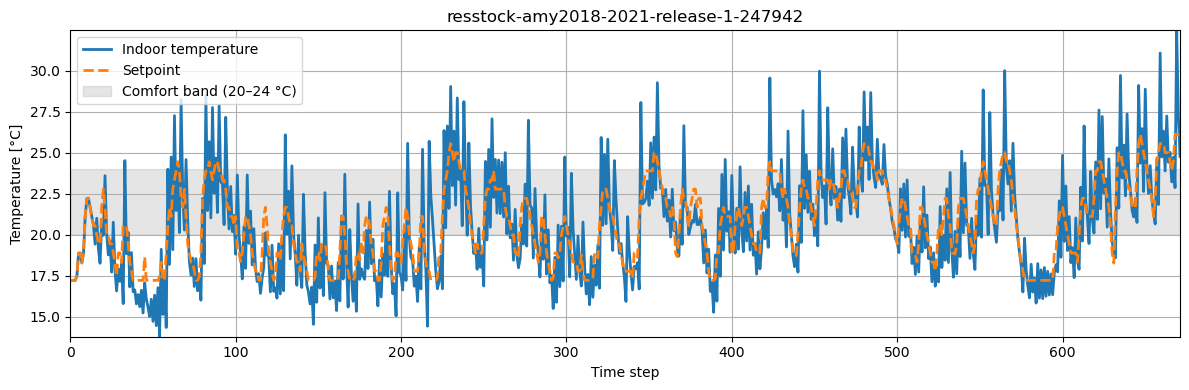

In [36]:
plot_comfort(feb_pi_env)


In [37]:
pi_kpis = feb_pi_env.evaluate()
print(pi_kpis)


                                    cost_function     value  \
0                           all_time_peak_average  0.941282   
1         annual_normalized_unserved_energy_total  0.000000   
2                          carbon_emissions_total       NaN   
3                                      cost_total       NaN   
4             daily_one_minus_load_factor_average  1.190129   
5                              daily_peak_average  0.998428   
6                   discomfort_cold_delta_average  0.851214   
7                   discomfort_cold_delta_maximum  5.089184   
8                   discomfort_cold_delta_minimum  0.000000   
9                      discomfort_cold_proportion  0.161832   
10                   discomfort_hot_delta_average  0.717768   
11                   discomfort_hot_delta_maximum  7.912468   
12                   discomfort_hot_delta_minimum  0.000000   
13                      discomfort_hot_proportion  0.145038   
14                          discomfort_proportion  0.30

# Train untrained RL online on February

/home/kostas/school/Y2/Zoltan/annex96_common_exercise_1/citylearn/dynamics.py:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(self.filepat

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


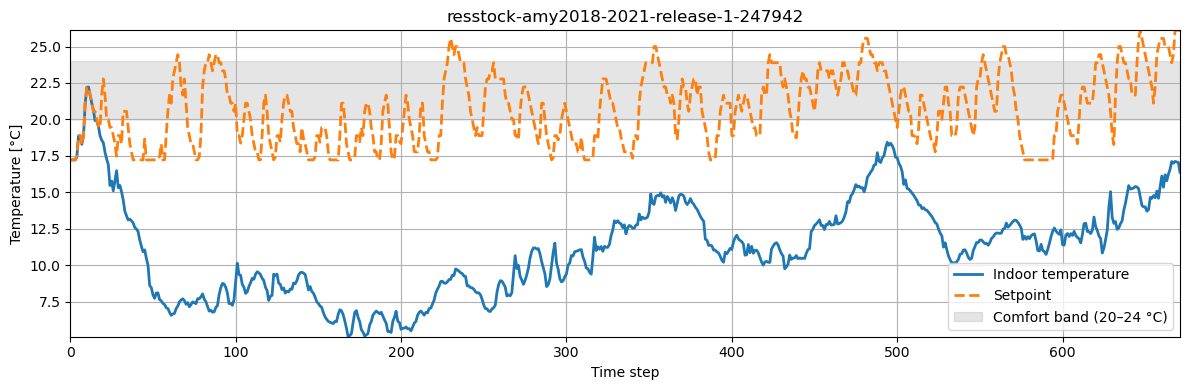

Fresh February KPIs:
                                    cost_function      value  \
0                           all_time_peak_average   0.805708   
1         annual_normalized_unserved_energy_total   0.000000   
2                          carbon_emissions_total        NaN   
3                                      cost_total        NaN   
4             daily_one_minus_load_factor_average   1.209979   
5                              daily_peak_average   0.871984   
6                   discomfort_cold_delta_average   9.199513   
7                   discomfort_cold_delta_maximum  17.345757   
8                   discomfort_cold_delta_minimum   0.000000   
9                      discomfort_cold_proportion   0.969466   
10                   discomfort_hot_delta_average   0.000300   
11                   discomfort_hot_delta_maximum   0.109802   
12                   discomfort_hot_delta_minimum   0.000000   
13                      discomfort_hot_proportion   0.000000   
14                 

In [31]:
from stable_baselines3 import SAC

# --- February env ---
feb_env = make_env(
    simulation_start_time_step=FEB_START,
    simulation_end_time_step=FEB_END,
    reward_function=ComfortReward,
)
feb_env = StableBaselines3Wrapper(feb_env)

# --- brand-new SAC (no pretraining) ---
fresh_model = SAC(
    policy="MlpPolicy",
    env=feb_env,
    seed=RANDOM_SEED,
    verbose=1,
)

# --- train for ONE February episode ---
FEB_TIMESTEPS = feb_env.unwrapped.time_steps - 1
fresh_model.learn(total_timesteps=FEB_TIMESTEPS)

# --- rollout again for visualization ---
obs, _ = feb_env.reset()
done = False

while not done:
    action, _ = fresh_model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, _ = feb_env.step(action)
    done = terminated or truncated

plot_comfort(feb_env)

print("Fresh February KPIs:")
print(feb_env.unwrapped.evaluate())


# Train pre-trained RL on February (1 episode)

In [42]:
jan_env = StableBaselines3Wrapper(make_env(reward_function=ComfortReward))
JAN_OBS_SPACE = jan_env.observation_space


/home/kostas/school/Y2/Zoltan/annex96_common_exercise_1/citylearn/dynamics.py:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(self.filepat

In [43]:
feb_env = make_env(
    simulation_start_time_step=FEB_START,
    simulation_end_time_step=FEB_END,
    reward_function=ComfortReward,
)
feb_env = StableBaselines3Wrapper(feb_env)

# 🔴 override Box to January bounds
feb_env.observation_space = JAN_OBS_SPACE


/home/kostas/school/Y2/Zoltan/annex96_common_exercise_1/citylearn/dynamics.py:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(self.filepat

In [44]:
from stable_baselines3 import SAC
from stable_baselines3.common.vec_env import DummyVecEnv

feb_vec_env = DummyVecEnv([lambda: feb_env])

warm_model = SAC.load("sac_offline_from_PI_28dim", env=feb_vec_env)

FEB_TIMESTEPS = feb_vec_env.envs[0].unwrapped.time_steps - 1
warm_model.learn(total_timesteps=FEB_TIMESTEPS, reset_num_timesteps=False)


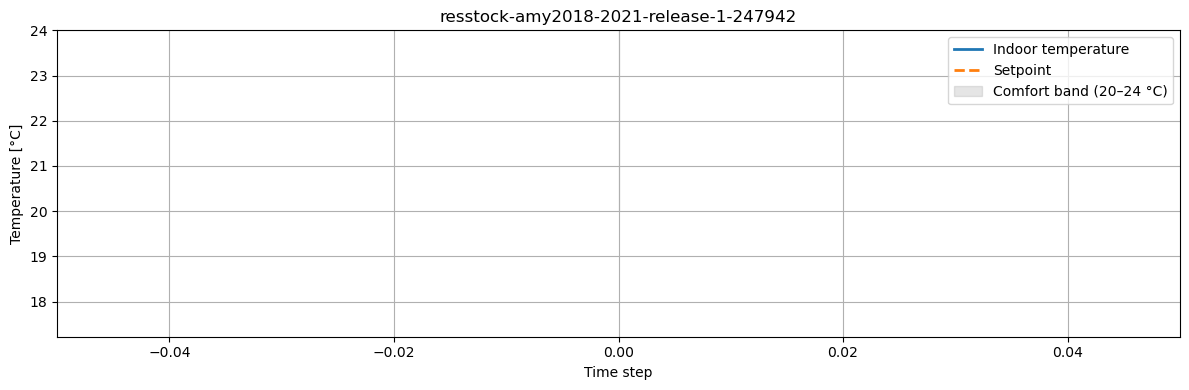

In [45]:
plot_comfort(feb_env)

/home/kostas/school/Y2/Zoltan/annex96_common_exercise_1/citylearn/dynamics.py:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(self.filepat

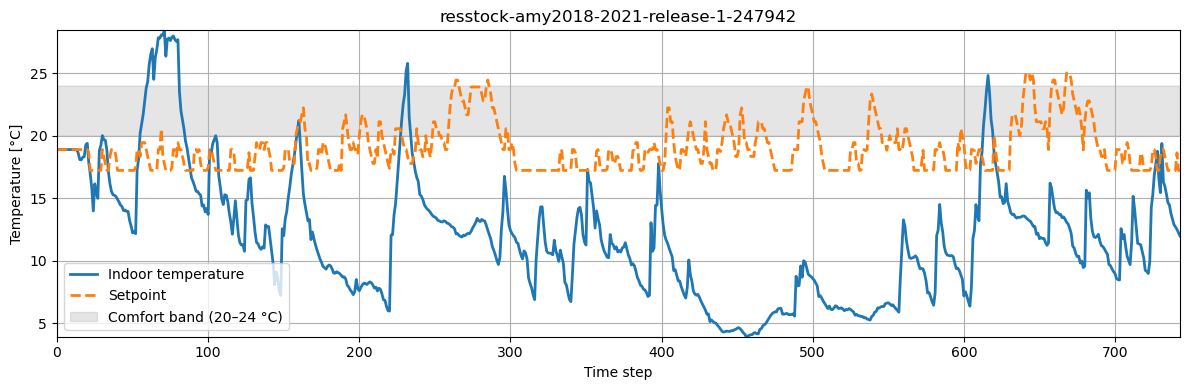

Warm-start February KPIs:
                                    cost_function      value  \
0                           all_time_peak_average   1.199990   
1         annual_normalized_unserved_energy_total   0.000000   
2                          carbon_emissions_total        NaN   
3                                      cost_total        NaN   
4             daily_one_minus_load_factor_average   1.279501   
5                              daily_peak_average   1.029661   
6                   discomfort_cold_delta_average   7.113373   
7                   discomfort_cold_delta_maximum  17.787239   
8                   discomfort_cold_delta_minimum   0.000000   
9                      discomfort_cold_proportion   0.832636   
10                   discomfort_hot_delta_average   0.414718   
11                   discomfort_hot_delta_maximum  10.635366   
12                   discomfort_hot_delta_minimum   0.000000   
13                      discomfort_hot_proportion   0.062762   
14            

In [46]:
# --- rollout again for visualization (new env for clean history) ---
feb_eval_env = make_env()

obs, _ = feb_eval_env.reset()
done = False

while not done:
    action, _ = warm_model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, _ = feb_eval_env.step(action)
    done = terminated or truncated

plot_comfort(feb_eval_env)

print("Warm-start February KPIs:")
print(feb_eval_env.unwrapped.evaluate())

/home/kostas/school/Y2/Zoltan/annex96_common_exercise_1/citylearn/dynamics.py:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(self.filepat

Using cuda device


/home/kostas/school/Y2/Zoltan/annex96_common_exercise_1/citylearn/dynamics.py:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(self.filepat

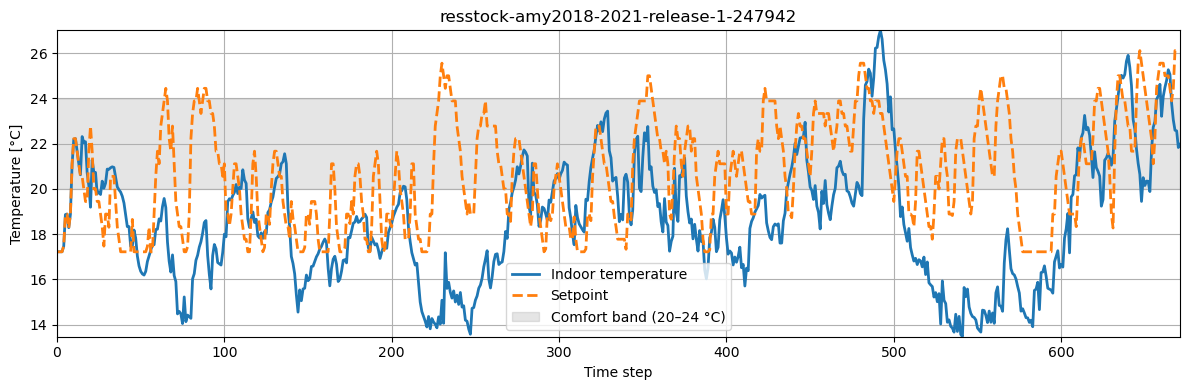

                                    cost_function      value  \
0                           all_time_peak_average   0.884271   
1         annual_normalized_unserved_energy_total   0.000000   
2                          carbon_emissions_total        NaN   
3                                      cost_total        NaN   
4             daily_one_minus_load_factor_average   1.035626   
5                              daily_peak_average   0.958983   
6                   discomfort_cold_delta_average   2.353055   
7                   discomfort_cold_delta_maximum  10.971587   
8                   discomfort_cold_delta_minimum   0.000000   
9                      discomfort_cold_proportion   0.470229   
10                   discomfort_hot_delta_average   0.356845   
11                   discomfort_hot_delta_maximum   3.673580   
12                   discomfort_hot_delta_minimum   0.000000   
13                      discomfort_hot_proportion   0.071756   
14                          discomfort_p

In [50]:
from stable_baselines3 import SAC
from stable_baselines3.common.vec_env import DummyVecEnv

# ---------- February VecEnv ----------
def make_feb_env():
    env = make_env(
        simulation_start_time_step=FEB_START,
        simulation_end_time_step=FEB_END,
        reward_function=ComfortReward,
    )
    return StableBaselines3Wrapper(env)

feb_vec = DummyVecEnv([make_feb_env])

# ---------- Fresh SAC on February ----------
model = SAC(
    "MlpPolicy",
    env=feb_vec,
    seed=RANDOM_SEED,
    verbose=1,
    ent_coef=10,   
    train_freq=1,
    # learning_rate=0.0003,
    # gradient_steps=,
)

# ---------- Load ONLY neural network weights from January ----------
jan_model = SAC.load("sac_offline_from_PI_28dim", env=None)

model.policy.load_state_dict(jan_model.policy.state_dict())

# ---------- Train for ONE February episode ----------
FEB_STEPS = feb_vec.envs[0].unwrapped.time_steps - 1
model.learn(total_timesteps=FEB_STEPS)

# ---------- Deterministic rollout for plotting ----------
feb_eval = make_feb_env()

obs, _ = feb_eval.reset()
done = False
while not done:
    act, _ = model.predict(obs, deterministic=True)
    obs, r, term, trunc, _ = feb_eval.step(act)
    done = term or trunc

plot_comfort(feb_eval)
print(feb_eval.unwrapped.evaluate())


In [28]:
print("model obs space:", model.observation_space)
print("feb vec obs space:", feb_vec.observation_space)


model obs space: Box([  1.           1.         -28.3          0.         -28.553085
 -28.357162   -28.898855     0.           0.           0.
  -2.7777786    0.38025025   0.           0.           0.
   0.          17.222221    17.222221     0.         -20.
 -20.           3.           0.          -4.4629707    0.
   0.           0.          -3.3       ], [  1.         24.         16.1       919.5        16.389288   16.424475
  16.613678  915.9976    905.3604    995.7681     44.999996    5.365362
  12.42885     0.         22.055605    1.6532834  25.         25.
   2.         20.         20.          3.          1.         23.21316
   0.          7.6920233   6.8557744   3.3      ], (28,), float32)
feb vec obs space: Box([  2.           1.         -18.3          0.         -18.51426
 -18.589092   -19.084635     0.           0.           0.
  -2.7777786    0.38001665   0.           0.           0.
   0.          17.222221    17.222221     0.         -20.
 -20.           3.           0.  

In [25]:
from stable_baselines3 import SAC

model = SAC.load("sac_offline_from_PI_28dim", env=None)


In [26]:
model.set_env(feb_vec, force_reset=False)

# Disable VecNormalize mismatch just in case
model._vec_normalize_env = None


ValueError: Observation spaces do not match: Box([  1.           1.         -28.3          0.         -28.553085
 -28.357162   -28.898855     0.           0.           0.
  -2.7777786    0.38025025   0.           0.           0.
   0.          17.222221    17.222221     0.         -20.
 -20.           3.           0.          -4.4629707    0.
   0.           0.          -3.3       ], [  1.         24.         16.1       919.5        16.389288   16.424475
  16.613678  915.9976    905.3604    995.7681     44.999996    5.365362
  12.42885     0.         22.055605    1.6532834  25.         25.
   2.         20.         20.          3.          1.         23.21316
   0.          7.6920233   6.8557744   3.3      ], (28,), float32) != Box([  2.           1.         -18.3          0.         -18.51426
 -18.589092   -19.084635     0.           0.           0.
  -2.7777786    0.38001665   0.           0.           0.
   0.          17.222221    17.222221     0.         -20.
 -20.           3.   

# Run Fully untrained RL on January

In [45]:
def rollout_episode(env, model):
    obs, _ = env.reset()
    done = False
    total_reward = 0.0

    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        total_reward += float(reward)

    return env, total_reward


In [46]:
def make_january_eval_env():
    env = make_env(reward_function=ComfortReward)
    env = StableBaselines3Wrapper(env)
    return env


In [150]:
from stable_baselines3 import SAC

env_untrained = make_january_eval_env()

untrained_sac = SAC(
    policy="MlpPolicy",
    env=env_untrained,
    seed=RANDOM_SEED,
    verbose=0,
)


/home/kostas/school/Y2/Zoltan/annex96_common_exercise_1/citylearn/dynamics.py:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(self.filepat

Untrained SAC reward: -177047.65896807614


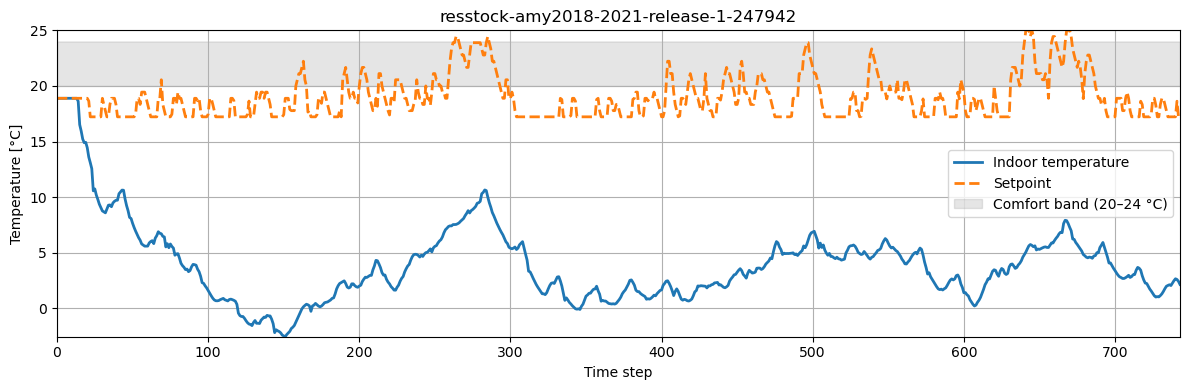

In [151]:
env_untrained, reward_untrained = rollout_episode(env_untrained, untrained_sac)

print("Untrained SAC reward:", reward_untrained)
plot_comfort(env_untrained)


In [39]:
FEB_DAYS = 28
FEB_START = SIMULATION_END_TIME_STEP + 1
FEB_END   = FEB_START + FEB_DAYS * 24 - 1


In [40]:
def make_period_env(start, end):
    env = make_env(
        reward_function=ComfortReward,
        simulation_start_time_step=start,
        simulation_end_time_step=end,
    )
    env = NormalizedObservationWrapper(env)   # ← IMPORTANT
    env = StableBaselines3Wrapper(env)
    return env


In [43]:
SIMULATION_START_TIME_STEP, SIMULATION_END_TIME_STEP
jan_env = make_period_env(SIMULATION_START_TIME_STEP, SIMULATION_END_TIME_STEP)

/home/kostas/school/Y2/Zoltan/annex96_common_exercise_1/citylearn/dynamics.py:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(self.filepat

# Train RL on 15 episodes on January, then test on February

In [61]:
from stable_baselines3 import SAC
from tqdm import tqdm

jan_env = make_period_env(SIMULATION_START_TIME_STEP, SIMULATION_END_TIME_STEP)

sac_model = SAC(
    policy="MlpPolicy",
    env=jan_env,
    seed=RANDOM_SEED,
    verbose=1,
)

sac_episodes = 15
timesteps = jan_env.unwrapped.time_steps - 1

for _ in tqdm(range(sac_episodes)):
    sac_model.learn(total_timesteps=timesteps, reset_num_timesteps=False)

sac_model.save("sac_trained_15eps_january_norm")


/home/kostas/school/Y2/Zoltan/annex96_common_exercise_1/citylearn/dynamics.py:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(self.filepat

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


 20%|██        | 3/15 [00:16<01:08,  5.74s/it]

----------------------------------
| rollout/           |           |
|    ep_len_mean     | 743       |
|    ep_rew_mean     | -1.14e+04 |
| time/              |           |
|    episodes        | 4         |
|    fps             | 128       |
|    time_elapsed    | 5         |
|    total_timesteps | 2972      |
| train/             |           |
|    actor_loss      | 168       |
|    critic_loss     | 253       |
|    ent_coef        | 1.01      |
|    ent_coef_loss   | 0.00223   |
|    learning_rate   | 0.0003    |
|    n_updates       | 2871      |
----------------------------------


 47%|████▋     | 7/15 [00:39<00:45,  5.71s/it]

----------------------------------
| rollout/           |           |
|    ep_len_mean     | 743       |
|    ep_rew_mean     | -6.19e+03 |
| time/              |           |
|    episodes        | 8         |
|    fps             | 127       |
|    time_elapsed    | 5         |
|    total_timesteps | 5944      |
| train/             |           |
|    actor_loss      | 179       |
|    critic_loss     | 139       |
|    ent_coef        | 0.655     |
|    ent_coef_loss   | 0.00373   |
|    learning_rate   | 0.0003    |
|    n_updates       | 5843      |
----------------------------------


 73%|███████▎  | 11/15 [01:03<00:23,  5.78s/it]

----------------------------------
| rollout/           |           |
|    ep_len_mean     | 743       |
|    ep_rew_mean     | -4.39e+03 |
| time/              |           |
|    episodes        | 12        |
|    fps             | 113       |
|    time_elapsed    | 6         |
|    total_timesteps | 8916      |
| train/             |           |
|    actor_loss      | 178       |
|    critic_loss     | 39.3      |
|    ent_coef        | 0.541     |
|    ent_coef_loss   | -0.0181   |
|    learning_rate   | 0.0003    |
|    n_updates       | 8815      |
----------------------------------


100%|██████████| 15/15 [01:28<00:00,  5.89s/it]


Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


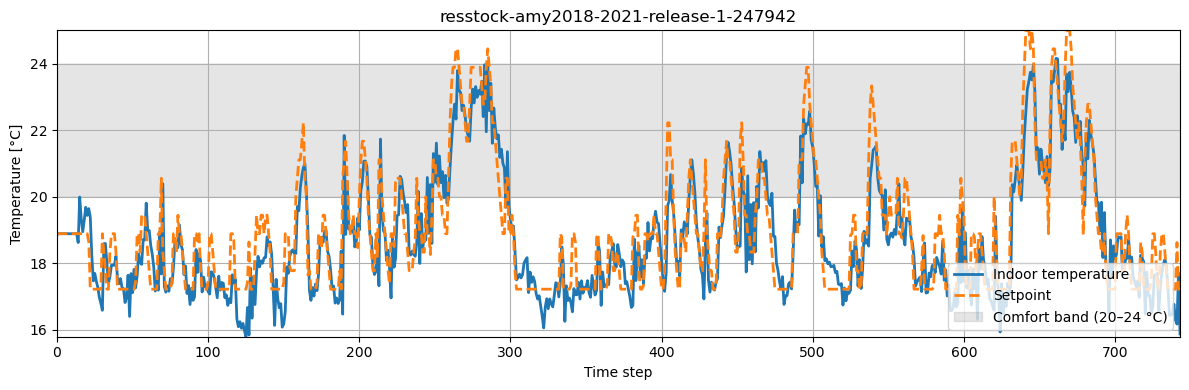

                                    cost_function     value  \
0                           all_time_peak_average  0.967056   
1         annual_normalized_unserved_energy_total  0.000000   
2                          carbon_emissions_total       NaN   
3                                      cost_total       NaN   
4             daily_one_minus_load_factor_average  1.027968   
5                              daily_peak_average  1.007196   
6                   discomfort_cold_delta_average  0.437136   
7                   discomfort_cold_delta_maximum  4.082966   
8                   discomfort_cold_delta_minimum  0.000000   
9                      discomfort_cold_proportion  0.043236   
10                   discomfort_hot_delta_average  0.221028   
11                   discomfort_hot_delta_maximum  2.164660   
12                   discomfort_hot_delta_minimum  0.000000   
13                      discomfort_hot_proportion  0.006974   
14                          discomfort_proportion  0.05

In [45]:
model = SAC.load("sac_trained_15eps_january_norm", env=jan_env)

obs, _ = jan_env.reset()
done = False

while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, _ = jan_env.step(action)
    done = terminated or truncated

plot_comfort(jan_env)
print(jan_env.unwrapped.evaluate())

/home/kostas/school/Y2/Zoltan/annex96_common_exercise_1/citylearn/dynamics.py:118: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(self.filepat

Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


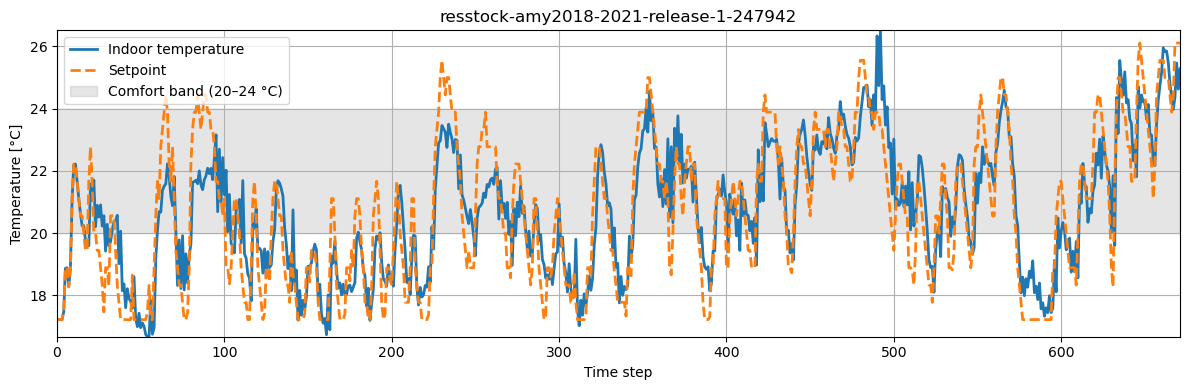

AttributeError: 'StableBaselines3Wrapper' object has no attribute 'rewards'

In [46]:
feb_env = make_period_env(FEB_START, FEB_END)

model = SAC.load("sac_trained_15eps_january_norm", env=feb_env)

obs, _ = feb_env.reset()
done = False

while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, _ = feb_env.step(action)
    done = terminated or truncated

plot_comfort(feb_env)
print("February total reward:", float(sum(feb_env.rewards)))


In [64]:
print(feb_env.unwrapped.evaluate())

                                    cost_function     value  \
0                           all_time_peak_average  0.948917   
1         annual_normalized_unserved_energy_total  0.000000   
2                          carbon_emissions_total       NaN   
3                                      cost_total       NaN   
4             daily_one_minus_load_factor_average  0.993435   
5                              daily_peak_average  1.001917   
6                   discomfort_cold_delta_average  0.438222   
7                   discomfort_cold_delta_maximum  2.859247   
8                   discomfort_cold_delta_minimum  0.000000   
9                      discomfort_cold_proportion  0.053435   
10                   discomfort_hot_delta_average  0.486548   
11                   discomfort_hot_delta_maximum  4.113190   
12                   discomfort_hot_delta_minimum  0.000000   
13                      discomfort_hot_proportion  0.038168   
14                          discomfort_proportion  0.09

In [174]:
obs, _ = jan_env.reset()
done = False

while not done:
    action, _ = sac_model.predict(obs, deterministic=True)
    obs, _, terminated, truncated, _ = jan_env.step(action)
    done = terminated or truncated

plot_comfort(jan_env)


AttributeError: 'TimeLimit' object has no attribute 'shared_observations'

In [16]:
from stable_baselines3 import SAC

# --- February env ---
feb_env = make_period_env(FEB_START, FEB_END)

# --- load model WITHOUT env ---
model = SAC.load("sac_trained_15eps_january_manual", env=None)

# --- BYPASS SB3 space check ---
model.env = feb_env
model._vec_normalize_env = None
model.n_envs = 1

# --- rollout February ---
obs, _ = feb_env.reset()
done = False

while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, _ = feb_env.step(action)
    done = terminated or truncated

# --- plot ---
plot_comfort(feb_env)
print("February total reward:", float(sum(feb_env.rewards)))


NameError: name 'make_period_env' is not defined